In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import torch
import gc
from IPython.display import display

ds_name = 'real_NCT00981058_inject'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
proj_name = 'SurvSurfBenchmark_NCT00981058_inject'
g_resol = 1
t_resol = 7
g_max = 5
split='test'

In [2]:
DEVICE = 'cpu'
if DEVICE == 'gpu':
    assert torch.cuda.is_available()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
else:
    device = 'cpu'

## Import and instantiate model

In [3]:
from dataset_NCT00981058 import DataModuleNCT00981058, DatasetNCT00981058

In [4]:
ds = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False,
)
df_obs = ds._get_df_Xy_trans_obs()
df_true_prob = ds._get_df_Xy_true_prob()
df_true_prob.loc[
    df_true_prob[ds.colname_g] == 6,:
].head()

,subject,duration,g_max_by_time,event_observed,weight,feat__AGE,feat__BLOOD AND LYMPHATIC SYSTEM DISORDERS,feat__BMIBL,feat__BSABL,feat__Body Surface Area (m^2),...,feat__SMKB_Smoker (all others),feat__SOCIAL CIRCUMSTANCES,feat__SURGICAL AND MEDICAL PROCEDURES,feat__Systolic Blood Pressure (mmHg),feat__Temperature (°C),feat__VASCULAR DISORDERS,"feat__WBCCAT1_> 11,000 µl (11 x 10^9/L)",feat__Weight (kg),feat__traj_clust,is_t_trans


In [5]:
df_true_prob['g_max_by_time'].value_counts()

g_max_by_time
1    2400
2    2400
3    2400
4    2400
5    2400
Name: count, dtype: int64

In [6]:
from model_eval_utils import (
    get_all_grades_start_end_time, 
)
def pred_by_counting(run_id, proj_name, split='val'):
    ds_train = DatasetNCT00981058(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        split='train', 
        mode='true_probs_grid', 
        separate_g_from_feats=False
    )
    
    ds_split = DatasetNCT00981058(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        split=split, 
        mode='true_probs_grid', 
        separate_g_from_feats=False
    )
    obs_full_traj = ds_train._get_df_Xy_full_traj_obs(g0_as_gres=False)
    out_dfs = dict()
    for flag, pred_holder in [
        ('obs', ds_split._get_df_Xy_trans_obs()),
        ('true_prob', ds_split._get_df_Xy_true_prob())
    ]:
        gs = pred_holder[ds_split.colname_g].unique()
        ts = pred_holder['duration'].unique()
        pred_holder['pred'] = np.nan
        pred_holder = pred_holder.rename(
            columns={
                ds_split.colname_g:'g',
                'duration':'t',
                'event_observed':'truth',
                ds_split.colname_traj_id:'subj'
            }
        )
        obs_trans_time_all_g = get_all_grades_start_end_time(obs_full_traj, gs=gs)
        assert all(obs_trans_time_all_g['g'].unique() == gs)
        for g, obs_trans_time in obs_trans_time_all_g.groupby('g'):
            for t in ts:
                event_observed =  obs_trans_time['event_observed'].astype(bool)
                time_happened = obs_trans_time['t_observed_or_censored'].astype(float)
                time_alive = obs_trans_time ['t_uncensored_alive'].astype(float)
                missing_exact_t = obs_trans_time['missing_exact_t'].astype(bool)
                
                is_case = (time_happened <= t) & event_observed 
                is_control_exact_t = (time_happened >= t) & ~event_observed
                is_control_inexact_t = (time_alive >= t) & missing_exact_t
                is_control = is_control_exact_t | is_control_inexact_t

                pred = sum(is_case)/(sum(is_case) + sum(is_control))

                selector = (pred_holder['g'] == g) & (pred_holder['t'] == t)
                pred_holder.loc[selector, 'pred'] = pred
        out_dfs[flag] = pred_holder
    return out_dfs, f'Count_from_train_intvl_imputed'

In [7]:
import xgboost as xgb
import pickle

def pred_from_xgboost_mono(run_id, proj_name, split='val'):
    if 'more_g' in run_id:
        path_trees = f'./xgboost_models/{proj_name}/more_g/{run_id}_trees.ubj'
        path_cph = f'./xgboost_models/{proj_name}/more_g/{run_id}_cph.pkl'
    else:
        path_trees = f'./xgboost_models/{proj_name}/{run_id}_trees.ubj'
        path_cph = f'./xgboost_models/{proj_name}/{run_id}_cph.pkl'
    
    ds = DatasetNCT00981058(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        t_resol=t_resol,
        split=split, 
        mode='first_cross_obs_only', 
        separate_g_from_feats=False,
    )

    df_obs = ds._get_df_Xy_trans_obs()
    input_var_selector = df_obs.columns.str.startswith('feat')|df_obs.columns.str.startswith('g_max_by_time')
    cols_inputs_obs = df_obs.columns[input_var_selector]
    df_true_prob = ds._get_df_Xy_true_prob()
    input_var_selector = df_true_prob.columns.str.startswith('feat')|df_true_prob.columns.str.startswith('g_max_by_time')
    cols_inputs_true_probs = df_true_prob.columns[input_var_selector]
    assert all(cols_inputs_obs == cols_inputs_true_probs)

    with open(path_cph, 'rb') as fp:
        cph=pickle.load(fp)
    xgboost_model = xgb.Booster()
    xgboost_model.load_model(path_trees)

    def pred_from_df(x):
        x_dmatrix = xgb.DMatrix(x)
        tree_results = pd.DataFrame({
            'xgb_risk': np.log(xgboost_model.predict(x_dmatrix)),
        })
        S = cph.predict_survival_function(tree_results).T
        return S

    assert (
        df_true_prob.groupby(['subject',ds.colname_g]).apply(
            lambda x: tuple(x['duration']),
            include_groups=False
        )
    ).nunique() == 1


    df_val_results_obs = []
    df_val_results_grid = []
    for g, df_obs_g in df_obs.groupby(ds.colname_g):
        if g > ds.g_max:
            continue
        df_true_prob_g = df_true_prob.loc[
            df_true_prob[ds.colname_g] == g,:
        ]

        n_unique_time_per_subj = (
            df_true_prob_g.groupby(['subject']).apply(
                lambda x: tuple(x['duration'].sort_values()),
                include_groups=False
            )
        ).nunique()
        assert n_unique_time_per_subj == 1, n_unique_time_per_subj
        x = df_obs_g[cols_inputs_obs].astype('float32')
        x['g_max_by_time'] = x['g_max_by_time']/ds.g_max
        curvs = pred_from_df(x)            
        
        for subj, (_, curv) in zip(df_obs_g['subject'], curvs.iterrows()):
            obs_g_subj = df_obs_g.loc[df_obs_g['subject'] == subj,:]
            assert obs_g_subj.shape[0] == 1
            obs_g_subj = obs_g_subj.iloc[0,:]
            t = obs_g_subj['duration']
            truth = obs_g_subj['event_observed']
            if t > curv.index.max():
                pred = curv.iloc[-1]
            else:
                pred = np.interp(t, xp=curv.index, fp=curv.values)
            row = {
                'subj':subj,
                'g':g,
                't':t,
                'pred':1-pred,
                'truth':truth
            }
            df_val_results_obs.append(row)

        
    for g, df_true_prob_g in df_true_prob.groupby(ds.colname_g):   
        df_true_prob_g_tless = df_true_prob_g.drop(columns=['duration','event_observed']).drop_duplicates()
        assert df_true_prob_g_tless['subject'].value_counts().max() == 1
        x = df_true_prob_g_tless[cols_inputs_obs].astype('float32')
        x['g_max_by_time'] = x['g_max_by_time']/ds.g_max
        curvs = pred_from_df(x)    

        for subj, (_, curv) in zip(df_true_prob_g_tless['subject'], curvs.iterrows()):
            df_val_subj_g = pd.DataFrame()
            df_true_prob_subj_g = df_true_prob_g.loc[
                df_true_prob_g['subject'] == subj,:
            ].sort_values('duration')
            t_grid = df_true_prob_subj_g['duration']
            t_grid_in_range = t_grid[t_grid <= curv.index.max()]
            t_grid_extrap = t_grid[t_grid > curv.index.max()]
            pred_prob_at_time_grid = np.interp(t_grid_in_range, xp=curv.index, fp=curv.values)
            pred_prob_at_time_grid = np.r_[pred_prob_at_time_grid, [pred_prob_at_time_grid[-1]]*t_grid_extrap.size]

            df_val_subj_g['t'] = t_grid
            df_val_subj_g['subj'] = subj
            df_val_subj_g['g'] = g
            df_val_subj_g['pred'] = 1-pred_prob_at_time_grid
            df_val_subj_g['truth'] = df_true_prob_subj_g['event_observed']
            df_val_results_grid.append(df_val_subj_g)
    out_dfs = dict()
    out_dfs['obs'] = pd.DataFrame(df_val_results_obs)
    out_dfs['true_prob'] = pd.concat(df_val_results_grid)
    return out_dfs, 'xgboost_mono'

In [8]:
import torchtuples as tt
from pycox.models.cox_time import MLPVanillaCoxTime
from pycox.models import CoxTime

def pred_from_pycox_coxtime(run_id, proj_name, split='val'):
    if 'more_g' in run_id:
        path = f'./pycox_models/more_g/{proj_name}/{run_id}'
    else:
        path = f'./pycox_models/{proj_name}/{run_id}'
    
    ds = DatasetNCT00981058(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        t_resol=t_resol,
        split=split, 
        mode='first_cross_obs_only', 
        separate_g_from_feats=False,
    )

    df_obs = ds._get_df_Xy_trans_obs()
    input_var_selector = df_obs.columns.str.startswith('feat')|df_obs.columns.str.startswith('g_max_by_time')
    cols_inputs_obs = df_obs.columns[input_var_selector]
    df_true_prob = ds._get_df_Xy_true_prob()
    input_var_selector = df_true_prob.columns.str.startswith('feat')|df_true_prob.columns.str.startswith('g_max_by_time')
    cols_inputs_true_probs = df_true_prob.columns[input_var_selector]
    assert all(cols_inputs_obs == cols_inputs_true_probs)

    in_features = len(cols_inputs_obs)
    num_nodes = [64, 64, 64, 64]
    batch_norm = False

    net = MLPVanillaCoxTime(in_features, num_nodes, batch_norm)
    model = CoxTime(net)
    model.load_net(path=path)
    assert (
        df_true_prob.groupby(['subject',ds.colname_g]).apply(
            lambda x: tuple(x['duration']),
            include_groups=False
        )
    ).nunique() == 1


    df_val_results_obs = []
    df_val_results_grid = []
    for g, df_obs_g in df_obs.groupby(ds.colname_g):
        if g > ds.g_max:
            continue
        df_true_prob_g = df_true_prob.loc[
            df_true_prob[ds.colname_g] == g,:
        ]

        n_unique_time_per_subj = (
            df_true_prob_g.groupby(['subject']).apply(
                lambda x: tuple(x['duration'].sort_values()),
                include_groups=False
            )
        ).nunique()
        assert n_unique_time_per_subj == 1, n_unique_time_per_subj
        x = df_obs_g[cols_inputs_obs].astype('float32')
        x['g_max_by_time'] = x['g_max_by_time']/ds.g_max
        curvs = model.predict_surv_df(x.values).T            
        
        for subj, (_, curv) in zip(df_obs_g['subject'], curvs.iterrows()):
            obs_g_subj = df_obs_g.loc[df_obs_g['subject'] == subj,:]
            assert obs_g_subj.shape[0] == 1
            obs_g_subj = obs_g_subj.iloc[0,:]
            t = obs_g_subj['duration']
            truth = obs_g_subj['event_observed']
            if t > curv.index.max():
                pred = curv.iloc[-1]
            else:
                pred = np.interp(t, xp=curv.index, fp=curv.values)
            row = {
                'subj':subj,
                'g':g,
                't':t,
                'pred':1-pred,
                'truth':truth
            }
            df_val_results_obs.append(row)

        
    for g, df_true_prob_g in df_true_prob.groupby(ds.colname_g):   
        df_true_prob_g_tless = df_true_prob_g.drop(columns=['duration','event_observed']).drop_duplicates()
        assert df_true_prob_g_tless['subject'].value_counts().max() == 1
        x = df_true_prob_g_tless[cols_inputs_obs].astype('float32')
        x['g_max_by_time'] = x['g_max_by_time']/ds.g_max
        curvs = model.predict_surv_df(x.values).T    

        for subj, (_, curv) in zip(df_true_prob_g_tless['subject'], curvs.iterrows()):
            df_val_subj_g = pd.DataFrame()
            df_true_prob_subj_g = df_true_prob_g.loc[
                df_true_prob_g['subject'] == subj,:
            ].sort_values('duration')
            t_grid = df_true_prob_subj_g['duration']
            t_grid_in_range = t_grid[t_grid <= curv.index.max()]
            t_grid_extrap = t_grid[t_grid > curv.index.max()]
            pred_prob_at_time_grid = np.interp(t_grid_in_range, xp=curv.index, fp=curv.values)
            pred_prob_at_time_grid = np.r_[pred_prob_at_time_grid, [pred_prob_at_time_grid[-1]]*t_grid_extrap.size]

            df_val_subj_g['t'] = t_grid
            df_val_subj_g['subj'] = subj
            df_val_subj_g['g'] = g
            df_val_subj_g['pred'] = 1-pred_prob_at_time_grid
            df_val_subj_g['truth'] = df_true_prob_subj_g['event_observed']
            df_val_results_grid.append(df_val_subj_g)
    out_dfs = dict()
    out_dfs['obs'] = pd.DataFrame(df_val_results_obs)
    out_dfs['true_prob'] = pd.concat(df_val_results_grid)
    return out_dfs, 'CoxTime'

In [9]:
import pickle
def pred_from_sksurv_joint(run_id, proj_name, split='val'):

    if 'more_g' in run_id:
        path_pickle = f'./sksurv_models/more_g/{proj_name}/Joint/{run_id}.pickle'
    else:
        path_pickle = f'./sksurv_models/{proj_name}/Joint/{run_id}.pickle'
    with open(path_pickle, 'rb') as f:
        model = pickle.load(f)
    
    ds = DatasetNCT00981058(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        t_resol=t_resol,
        split=split, 
        mode='first_cross_obs_only', 
        separate_g_from_feats=False,
    )
    df_obs = ds._get_df_Xy_trans_obs()
    df_true_prob = ds._get_df_Xy_true_prob()
    assert (
        df_true_prob.groupby(['subject',ds.colname_g]).apply(
            lambda x: tuple(x['duration']),
            include_groups=False
        )
    ).nunique() == 1


    cols_X = np.r_[[ds.colname_g], df_obs.columns[df_obs.columns.str.startswith('feat')]]      

    df_val_results_obs = []
    df_val_results_grid = []
    for g, df_obs_g in df_obs.groupby(ds.colname_g):
        if g > ds.g_max:
            continue
        df_true_prob_g = df_true_prob.loc[
            df_true_prob[ds.colname_g] == g,:
        ]

        n_unique_time_per_subj = (
            df_true_prob_g.groupby(['subject']).apply(
                lambda x: tuple(x['duration'].sort_values()),
                include_groups=False
            )
        ).nunique()
        assert n_unique_time_per_subj == 1, n_unique_time_per_subj
        
        curvs = model.predict_survival_function(df_obs_g[cols_X])
                
        
        for subj, curv in zip(df_obs_g['subject'], curvs):
            obs_g_subj = df_obs_g.loc[df_obs_g['subject'] == subj,:]
            assert obs_g_subj.shape[0] == 1
            obs_g_subj = obs_g_subj.iloc[0,:]
            t = obs_g_subj['duration']
            truth = obs_g_subj['event_observed']
            if t > curv.x.max():
                pred = curv(curv.x.max())
            else:
                pred = curv(t)
            row = {
                'subj':subj,
                'g':g,
                't':t,
                'pred':1-pred,
                'truth':truth
            }
            df_val_results_obs.append(row)

    for g, df_true_prob_g in df_true_prob.groupby(ds.colname_g):   
        df_true_prob_g_tless = df_true_prob_g.drop(columns=['duration','event_observed']).drop_duplicates()
        assert df_true_prob_g_tless['subject'].value_counts().max() == 1
        curvs = model.predict_survival_function(df_true_prob_g_tless[cols_X])

        for subj, curv in zip(df_true_prob_g_tless['subject'], curvs):
            df_val_subj_g = pd.DataFrame()
            df_true_prob_subj_g = df_true_prob_g.loc[
                df_true_prob_g['subject'] == subj,:
            ].sort_values('duration')
            t_grid = df_true_prob_subj_g['duration']
            t_grid_in_range = t_grid[t_grid <= curv.x.max()]
            t_grid_extrap = t_grid[t_grid > curv.x.max()]
            pred_prob_at_time_grid = curv(t_grid_in_range)
            pred_prob_at_time_grid = np.r_[pred_prob_at_time_grid, [pred_prob_at_time_grid[-1]]*t_grid_extrap.size]

            df_val_subj_g['t'] = t_grid
            df_val_subj_g['subj'] = subj
            df_val_subj_g['g'] = g
            df_val_subj_g['pred'] = 1-pred_prob_at_time_grid
            df_val_subj_g['truth'] = df_true_prob_subj_g['event_observed']
            df_val_results_grid.append(df_val_subj_g)

    out_dfs = dict()
    out_dfs['obs'] = pd.DataFrame(df_val_results_obs)
    out_dfs['true_prob'] = pd.concat(df_val_results_grid)
    return out_dfs, f'Joint_{model.__class__.__name__}'

In [10]:
def pred_from_DeepHit(run_id, proj_name, split='val'):
    import wandb
    from model_factory_deephit import LitModelDeepHit
    torch.set_float32_matmul_precision('medium')

    api = wandb.Api()
    # artifact = api.artifact(f'yichenchen-wings/{proj_name}/model-{run_id}:v0', type='model')
    # checkpoint_dir = artifact.download()
    checkpoint_dir = f'/home/yc366/repos/survsurf_benchmark/runtime_results/{proj_name}/{run_id}/checkpoints/'
    os.listdir(checkpoint_dir)[0]
    #path_checkpoint = os.path.join(checkpoint_dir, 'model.ckpt')
    path_checkpoint = os.path.join(checkpoint_dir, os.listdir(checkpoint_dir)[0])
    model_lit = LitModelDeepHit.load_from_checkpoint(path_checkpoint)
    
    datamodule = DataModuleNCT00981058(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        t_resol=t_resol,
        separate_g_from_feats=False, 
        train_mode='first_cross_obs_only',
        eval_mode='true_probs_grid',
        batch_size=100, 
        num_workers=4)
    datamodule.setup(stage=split)
    if 'val' in split:
        dataloader_obs, dataloader_true_prob = datamodule.val_dataloader()
    if 'test' in split:
        dataloader_obs, dataloader_true_prob = datamodule.test_dataloader()

    with torch.no_grad():
        torch.cuda.empty_cache()
    gc.collect()

    model_loaded_core = model_lit.model
    model_loaded_core = model_loaded_core.to(device)
    model_loaded_core.eval()

    t_size = model_lit.loss_brier.t_size
    t_res = model_lit.loss_brier.t_res

    out_dfs = dict()
    for key, dataloader in [
        ('obs', dataloader_obs),
        ('true_prob', dataloader_true_prob)
    ]:
        
        out_dfs = dict()
    for key, dataloader in [
        ('obs', dataloader_obs),
        ('true_prob', dataloader_true_prob)
    ]:
        subjs = []
        g = []
        t = []
        pred = []
        truth = []
        with torch.no_grad():
            for batch_, (subj, xs, ts, ys, weight, _) in enumerate(dataloader):
                xs, ts, ys = xs.to(device), ts.to(device), ys.to(device)
                out = model_loaded_core.forward_cif(xs)
                assert out.dim() == 3, f'found output with n dim = {out.dim()}, expecting a 3d tensor.'
                assert out.shape[1] == 1, f'found output with second dim = {out.shape[1]}, expecting 1.'
                out = out.reshape(out.shape[0], out.shape[-1])

                t_matrix = ts.repeat(1, t_size)
                
                t_matrix_ref = torch.linspace(0, t_size-1, steps=t_size)*t_res
                t_matrix_ref = t_matrix_ref.repeat(xs.shape[0], 1)

                selector_where_t = torch.logical_and(t_matrix_ref >= t_matrix,  t_matrix_ref < (t_matrix + t_res))
                assert torch.all(selector_where_t.sum(dim=-1) == 1)
                out = out[selector_where_t].reshape(xs.shape[0])

                subjs += list(subj)
                g += list(datamodule.g_max*xs.cpu().numpy()[:,-1])
                t += list(ts.cpu().numpy()[:,0])
                truth += list(ys.cpu().numpy()[:,0])
                pred += list(out.cpu().numpy())


        pred = np.array(pred)
        truth = np.array(truth)
        df_val_results = pd.DataFrame()
        df_val_results['subj'] = subjs
        df_val_results['g'] = g
        df_val_results['t'] = t
        df_val_results['pred'] = pred
        df_val_results['truth'] = truth
        for col in ['pred', 'truth']:
            df_val_results[col] = df_val_results[col].astype(float)
        out_dfs[key] = df_val_results
    return out_dfs, model_loaded_core.__class__.__name__


In [11]:

def pred_from_SurvSurf(run_id, proj_name, split='val'):
    import wandb
    from model_factory_survsurf import LitModelSurvSurf
    torch.set_float32_matmul_precision('medium')

    api = wandb.Api()
    # artifact = api.artifact(f'yichenchen-wings/{proj_name}/model-{run_id}:v0', type='model')
    # checkpoint_dir = artifact.download()
    checkpoint_dir = f'/home/yc366/repos/survsurf_benchmark/runtime_results/{proj_name}/{run_id}/checkpoints/'
    os.listdir(checkpoint_dir)[0]
    #path_checkpoint = os.path.join(checkpoint_dir, 'model.ckpt')
    path_checkpoint = os.path.join(checkpoint_dir, os.listdir(checkpoint_dir)[0])
    model_lit = LitModelSurvSurf.load_from_checkpoint(path_checkpoint)
    
    datamodule = DataModuleNCT00981058(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        t_resol=t_resol,
        separate_g_from_feats=True, 
        train_mode='first_cross_obs_only',
        eval_mode='true_probs_grid',
        batch_size=100, 
        num_workers=4)
    datamodule.setup(stage=split)
    if 'val' in split:
        dataloader_obs, dataloader_true_prob = datamodule.val_dataloader()
    if 'test' in split:
        dataloader_obs, dataloader_true_prob = datamodule.test_dataloader()

    with torch.no_grad():
        torch.cuda.empty_cache()
    gc.collect()

    model_loaded_core = model_lit.model
    model_loaded_core = model_loaded_core.to(device)
    model_loaded_core.eval()


    out_dfs = dict()
    for key, dataloader in [
        ('obs', dataloader_obs),
        ('true_prob', dataloader_true_prob)
    ]:
        
        subjs = []
        g = []
        t = []
        pred = []
        truth = []
        with torch.no_grad():
            for batch_, (subj, xs, gs, ts, ys, weight, _) in enumerate(dataloader):
                xs, gs, ts, ys = xs.to(device), gs.to(device), ts.to(device), ys.to(device)
                out = model_loaded_core(ts, gs, xs)
                subjs += list(subj)
                g += list(datamodule.g_max*gs.cpu().numpy()[:,0])
                t += list(ts.cpu().numpy()[:,0])
                truth += list(ys.cpu().numpy()[:,0])
                pred += list(out.cpu().numpy()[:,0])


        pred = np.array(pred)
        truth = np.array(truth)
        df_val_results = pd.DataFrame()
        df_val_results['subj'] = subjs
        df_val_results['g'] = g
        df_val_results['t'] = t
        df_val_results['pred'] = pred
        df_val_results['truth'] = truth
        for col in ['pred', 'truth']:
            df_val_results[col] = df_val_results[col].astype(float)
        out_dfs[key] = df_val_results
    return out_dfs, model_loaded_core.__class__.__name__


In [12]:


ds_train = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split='train', 
    mode='true_probs_grid', 
    separate_g_from_feats=False
)
ds_val = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split='val', 
    mode='true_probs_grid', 
    separate_g_from_feats=False
)
ds_test = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split='test', 
    mode='true_probs_grid', 
    separate_g_from_feats=False
)

In [13]:
ds_test._get_df_Xy_trans_obs()['g_max_by_time'].value_counts()

g_max_by_time
2.0    66
1.0    65
3.0    64
4.0    45
5.0    17
6.0     2
Name: count, dtype: int64

## Define metrics

In [14]:
from model_eval_utils import (
    get_brier_and_auc, 
    get_all_grades_start_end_time, 
    get_integrated_brier_intrvl_imputed, 
)

In [15]:
if split == 'val':
    gs = ds_val._get_df_Xy_true_prob()[ds_val.colname_g].unique()
if split == 'test':
    gs = ds_test._get_df_Xy_true_prob()[ds_val.colname_g].unique()

In [16]:
gs

array([1, 2, 3, 4, 5])

min censoring S(t) for g = 0.6630876406573092
min censoring S(t) for g = 0.5079484063282824
min censoring S(t) for g = 0.2326061655782763
min censoring S(t) for g = 0.0
min censoring S(t) for g = 0.0


/tmp/ipykernel_25581/762712767.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df_max_g_by_t_obs.groupby('subject').apply(lambda df: _get_last_obs_time(df, g))
/tmp/ipykernel_25581/762712767.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df_max_g_by_t_obs.groupby('subject').apply(lambda df: _get_last_obs_time(df, g))
/tmp/ipykernel_25581/762712767.py:9: DeprecationWarning: DataFrameGroupB

[Text(0, 0.5, 'S(t) for censoring'), Text(0.5, 0, 't')]

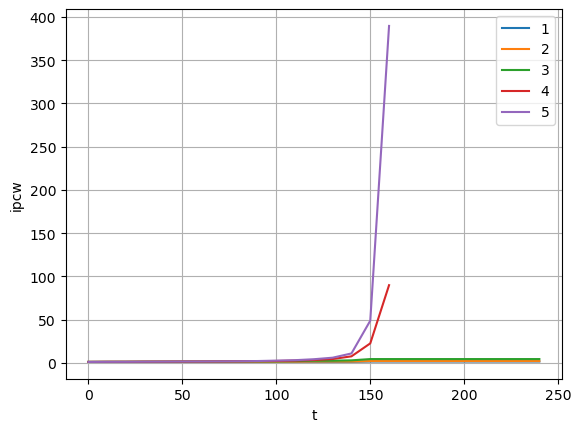

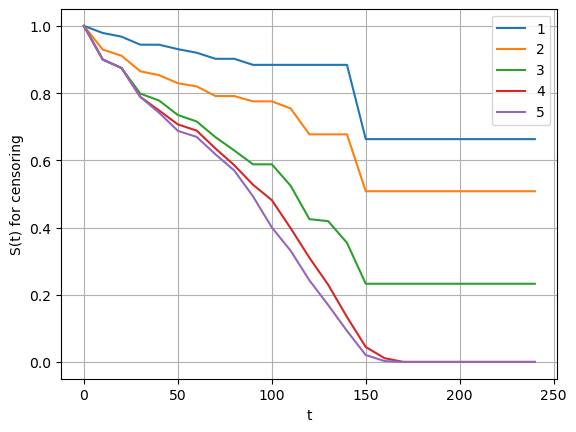

In [17]:
from sksurv.nonparametric import kaplan_meier_estimator
from model_eval_utils import _get_last_obs_time

def get_pre_censoring_t(df_dir, ds_name, gs, split):
    path_max_g_by_t_obs = os.path.join(df_dir,f'{ds_name}__df_state_history_sampled_max_{split}.csv')
    df_max_g_by_t_obs = pd.read_csv(path_max_g_by_t_obs, index_col=0)
    df_out = []
    for g in gs:
        df = df_max_g_by_t_obs.groupby('subject').apply(lambda df: _get_last_obs_time(df, g))
        df_out.append(df)
    df_out = pd.concat(df_out)
    return df_out

class IPCW:
    def __init__(self, time, S_censor):
        self.time = time
        self.S_censor = S_censor
    def __call__(self,t):
        S_censor = self.S_censor
        # percentile  = np.percentile(S_censor, 10)
        # S_censor[S_censor <= percentile] = percentile
        S = np.interp(t, self.time, S_censor)
        return 1/S

def get_train_ipcw(df_event_g_at_t_obs):
    df_event_g_at_t_obs = df_event_g_at_t_obs
    g_to_censor_curv = dict()
    for g, df_event_t in df_event_g_at_t_obs.groupby('g'):
        df_event_t = df_event_t.sort_values('duration')
        time, S_censor = kaplan_meier_estimator(df_event_t['event_observed'].astype(bool), df_event_t['duration'], reverse=True)
        if 0 not in time:
            time = np.r_[[0.], time]
            S_censor = np.r_[[1.], S_censor]
        g_to_censor_curv[g] = IPCW(time, S_censor)
    return g_to_censor_curv

df_last_obs_time_split = get_pre_censoring_t(df_dir=ds_df_dir,ds_name=ds_name, gs=gs, split=split)
df_last_obs_time_split = df_last_obs_time_split.loc[df_last_obs_time_split['g'] <= g_max, :]
df_train_obs_censor_less = df_last_obs_time_split.copy()
df_train_obs_censor_less['event_observed'] = True
df_train_obs_censor_less['duration'] = df_train_obs_censor_less['duration'].astype(float)
dict_ipcw = get_train_ipcw(df_last_obs_time_split)

fig, ax = plt.subplots(1,1,)
for g in [1,2,3,4,5]:
    x = np.arange(0, 250,10)
    y = dict_ipcw[g](x)
    ax.plot(x, y, label=g),
ax.legend()
ax.grid()
ax.set(ylabel='ipcw', xlabel='t')


fig, ax = plt.subplots(1,1,)
for g in [1,2,3,4,5]:
    x = np.arange(0, 250,10)
    y = 1/dict_ipcw[g](x)
    print(f'min censoring S(t) for g = {y.min()}')
    ax.plot(x, y, label=g),
ax.legend()
ax.grid()
ax.set(ylabel='S(t) for censoring', xlabel='t')

## Eval models

Text(0.5, 0, 'time $t$')

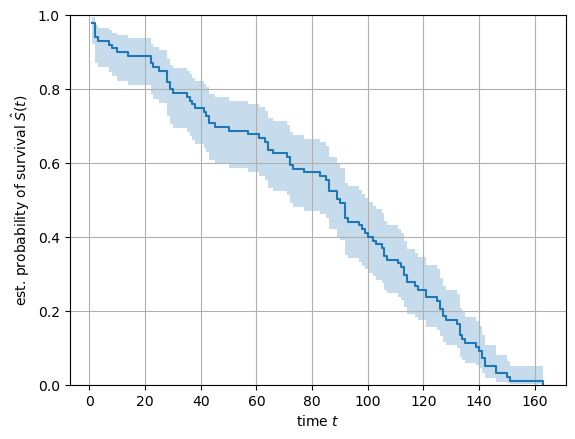

In [18]:
df_last_obs_time_split_subj = df_last_obs_time_split.loc[
    df_last_obs_time_split['g'] == g_max,:
]
time, survival_prob, conf_int = kaplan_meier_estimator(
    ~df_last_obs_time_split_subj["event_observed"], df_last_obs_time_split_subj["duration"], conf_type="log-log"
)

fig, ax = plt.subplots(1,1)
ax.step(time, survival_prob, where="post")
ax.grid()
plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")

In [19]:
if split == 'test':
    obs_full_traj = ds_test._get_df_Xy_full_traj_obs(g0_as_gres=False)
elif split == 'val':
    obs_full_traj = ds_val._get_df_Xy_full_traj_obs(g0_as_gres=False)
else:
    raise NotImplementedError
obs_trans_time_all_g = get_all_grades_start_end_time(obs_full_traj, gs=gs)

In [20]:
obs_full_traj['duration'].max()

163.0

In [21]:
obs_trans_time_all_g

,subject,g,event_observed,t_observed_or_censored,t_uncensored_alive,missing_exact_t
0,b'014-7882',1,True,2.0,0.0,True
1,b'014-7882',2,True,2.0,NaN,False
2,b'014-7882',3,False,25.0,NaN,False
3,b'014-7882',4,False,25.0,NaN,False
4,b'014-7882',5,False,25.0,NaN,False
...,...,...,...,...,...,...
0,b'721-7880',1,True,4.0,NaN,False
1,b'721-7880',2,True,8.0,NaN,False
2,b'721-7880',3,False,83.0,NaN,False
3,b'721-7880',4,False,83.0,NaN,False


In [22]:
obs_trans_time_all_g.groupby('g').apply(
    lambda x: pd.Series(
        [
            x.loc[
                x['event_observed'].astype(bool),
                't_observed_or_censored'
            ].max(),
            x.loc[
                ~x['event_observed'].astype(bool),
                't_observed_or_censored'
            ].max(),
            x['t_uncensored_alive'].max(),
        ],
        index=['t_observed', 'censored','t_uncensored_alive']
    )
)

/tmp/ipykernel_25581/1312802341.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  obs_trans_time_all_g.groupby('g').apply(


,t_observed,censored,t_uncensored_alive
g,,,
1,113.0,146.0,0.0
2,86.0,146.0,44.0
3,133.0,146.0,95.0
4,151.0,163.0,48.0
5,55.0,163.0,NaN


In [23]:
max_time = 140

In [ ]:
model_to_metric = []
model_to_prop_t_violated_per_subj = []
model_to_max_violated_per_subj = []
for run_id, pred_fun, descriptor in [
    ('pred_by_counting_train', pred_by_counting, 'standard'),

    ('8n2sgazv',pred_from_DeepHit,'LossSumo'),
    ('zxvcnylw',pred_from_DeepHit,'LossSumo'),
    ('sb5p2jxu',pred_from_DeepHit,'LossSumo'),
    ('34citj9l',pred_from_DeepHit,'LossSumo'),
    ('7mvbcrq7',pred_from_DeepHit,'LossSumo'),

    ('tcjqptb2',pred_from_DeepHit,'LossSumo(more g)'),
    ('xeiqaiin',pred_from_DeepHit,'LossSumo(more g)'),
    ('n4wh25m1',pred_from_DeepHit,'LossSumo(more g)'),
    ('fnvw90zb',pred_from_DeepHit,'LossSumo(more g)'),
    ('99dnj00b',pred_from_DeepHit,'LossSumo(more g)'),
    
    ('yjzof5h0',pred_from_DeepHit,'LossDyDg'),
    ('n1ygcpco',pred_from_DeepHit,'LossDyDg'),
    ('7z0167wj',pred_from_DeepHit,'LossDyDg'),
    ('rt97ko7u',pred_from_DeepHit,'LossDyDg'),
    ('zhr740qf',pred_from_DeepHit,'LossDyDg'),

    ('vtcx5w3i',pred_from_SurvSurf,'LossDyDg'),
    ('hzqo3sht',pred_from_SurvSurf,'LossDyDg'),
    ('cfbutii5',pred_from_SurvSurf,'LossDyDg'),
    ('0sufz7bb',pred_from_SurvSurf,'LossDyDg'),
    ('2nhi9xfc',pred_from_SurvSurf,'LossDyDg'),

    ('cox_time_pycox_10',pred_from_pycox_coxtime, 'standard'),
    ('cox_time_pycox_20',pred_from_pycox_coxtime, 'standard'),
    ('cox_time_pycox_30',pred_from_pycox_coxtime, 'standard'),
    ('cox_time_pycox_40',pred_from_pycox_coxtime, 'standard'),
    ('cox_time_pycox_50',pred_from_pycox_coxtime, 'standard'),

    ('cox_time_pycox_more_g_10',pred_from_pycox_coxtime, 'standard(more g)'),
    ('cox_time_pycox_more_g_20',pred_from_pycox_coxtime, 'standard(more g)'),
    ('cox_time_pycox_more_g_30',pred_from_pycox_coxtime, 'standard(more g)'),
    ('cox_time_pycox_more_g_40',pred_from_pycox_coxtime, 'standard(more g)'),
    ('cox_time_pycox_more_g_50',pred_from_pycox_coxtime, 'standard(more g)'),
         
    ('Joint_CoxnetSurvivalAnalysis_seed_10',pred_from_sksurv_joint, 'standard'),
    ('Joint_CoxPHSurvivalAnalysis_seed_10',pred_from_sksurv_joint, 'standard'),
    ('xgboost_mono_10',pred_from_xgboost_mono, 'standard'),
    ('xgboost_mono_more_g_10',pred_from_xgboost_mono, 'standard(more g)'),

    ('Joint_GradientBoostingSurvivalAnalysis_seed_10',pred_from_sksurv_joint, 'standard'),
    # ('Joint_GradientBoostingSurvivalAnalysis_seed_20',pred_from_sksurv_joint, 'standard'),
    # ('Joint_GradientBoostingSurvivalAnalysis_seed_30',pred_from_sksurv_joint, 'standard'),
    # ('Joint_GradientBoostingSurvivalAnalysis_seed_40',pred_from_sksurv_joint, 'standard'),
    # ('Joint_GradientBoostingSurvivalAnalysis_seed_50',pred_from_sksurv_joint, 'standard'),

    ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_10',pred_from_sksurv_joint, 'standard(more g)'),
    # ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_20',pred_from_sksurv_joint, 'standard(more g)'),
    # ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_30',pred_from_sksurv_joint, 'standard(more g)'),
    # ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_40',pred_from_sksurv_joint, 'standard(more g)'),
    # ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_50',pred_from_sksurv_joint, 'standard(more g)'),

    ('Joint_RandomSurvivalForest_seed_10',pred_from_sksurv_joint, 'standard'),
    ('Joint_RandomSurvivalForest_seed_20',pred_from_sksurv_joint, 'standard'),
    ('Joint_RandomSurvivalForest_seed_30',pred_from_sksurv_joint, 'standard'),
    ('Joint_RandomSurvivalForest_seed_40',pred_from_sksurv_joint, 'standard'),
    ('Joint_RandomSurvivalForest_seed_50',pred_from_sksurv_joint, 'standard'),

    ('Joint_RandomSurvivalForest_more_g_seed_10',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_RandomSurvivalForest_more_g_seed_20',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_RandomSurvivalForest_more_g_seed_30',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_RandomSurvivalForest_more_g_seed_40',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_RandomSurvivalForest_more_g_seed_50',pred_from_sksurv_joint, 'standard(more g)'),
]:
    out_model, model_name = pred_fun(run_id=run_id, proj_name=proj_name, split=split)
    intrg_brier_ipcw_by_subj, mean_auc_ipcw_by_subj = get_brier_and_auc(
        out_model, 
        df_last_obs_time_split, 
        ipcw='by_subj', 
        max_time=max_time,
        max_grade=g_max
    )

    intrg_brier_intrvl_imputed_ipcw_by_sbj = get_integrated_brier_intrvl_imputed(
        obs_trans_time_all_g, 
        out_model, 
        df_last_obs_time_split, 
        ipcw='by_subj', 
        max_time=max_time,
        max_grade=g_max
    )
    intrg_brier_intrvl_imputed = get_integrated_brier_intrvl_imputed(
        obs_trans_time_all_g, 
        out_model, 
        df_last_obs_time_split, 
        ipcw='without_ipcw', 
        max_time=max_time,
        max_grade=g_max
    )
    model_to_metric.append(
        {
            'run_id':run_id,
            'model_type':model_name,
            'intrg_brier_ipcw_by_subj':intrg_brier_ipcw_by_subj,
            'mean_auc_ipcw_by_subj':mean_auc_ipcw_by_subj,
            'intrg_brier_intrvl_imputed_ipcw_by_sbj':intrg_brier_intrvl_imputed_ipcw_by_sbj,
            'intrg_brier_intrvl_imputed':intrg_brier_intrvl_imputed,
            'descriptor':descriptor
        }
    )

    df = out_model['true_prob'].groupby(['subj','t']).apply(
        lambda x: (x.sort_values('g')['pred'].diff()> 0).any(),
        include_groups=False
    ).rename('any_violation').reset_index()
    df_fract_t_violated_per_subj = df.groupby('subj')['any_violation'].mean().reset_index()

    df = out_model['true_prob'].groupby(['subj','t']).apply(
        lambda x: (x.sort_values('g')['pred'].diff().max()),
        include_groups=False
    ).rename('max_violation').reset_index()
    df_fract_t_violated_per_subj['max_violation'] = df_fract_t_violated_per_subj['subj'].map(
        df.groupby('subj')['max_violation'].max()
    )
    row = df_fract_t_violated_per_subj['any_violation'].describe().to_dict()
    row['model_type'] = model_name
    row['run_id'] = run_id
    row['descriptor'] = descriptor
    model_to_prop_t_violated_per_subj.append(row)


    row = df_fract_t_violated_per_subj.loc[
        df_fract_t_violated_per_subj['any_violation'] > 0,
        'max_violation'
    ].describe().to_dict()
    row['model_type'] = model_name
    row['run_id'] = run_id
    model_to_max_violated_per_subj.append(row)
    print(f'finished processing {run_id}')

df_prop_t_violated_per_subj = pd.DataFrame(model_to_prop_t_violated_per_subj)
df_max_violated_per_subj = pd.DataFrame(model_to_max_violated_per_subj)
df_model_to_metric = pd.DataFrame(model_to_metric)
del model_to_prop_t_violated_per_subj
del model_to_max_violated_per_subj
del model_to_metric

/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, gs_higher_df])
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, gs_higher_df])
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude emp

finished processing pred_by_counting_train


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, gs_higher_df])
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude 

finished processing 8n2sgazv


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, gs_higher_df])
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude 

...

finished processing Joint_RandomSurvivalForest_more_g_seed_30


/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, gs_higher_df])
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, gs_higher_df])
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude emp

finished processing Joint_RandomSurvivalForest_more_g_seed_40


/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, gs_higher_df])
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, gs_higher_df])
/home/yc366/repos/survsurf_benchmark/model_eval_utils.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude emp

finished processing Joint_RandomSurvivalForest_more_g_seed_50


In [25]:
df_model_to_metric['median_prop_t_violated'] = df_model_to_metric['run_id'].map(
    df_prop_t_violated_per_subj.set_index('run_id')['50%']
)
df_model_to_metric['median_max_violation'] = df_model_to_metric['run_id'].map(
    df_max_violated_per_subj.set_index('run_id')['50%']
)
df_model_to_metric['max_prop_t_violated'] = df_model_to_metric['run_id'].map(
    df_prop_t_violated_per_subj.set_index('run_id')['max']
)
df_model_to_metric['max_max_violation'] = df_model_to_metric['run_id'].map(
    df_max_violated_per_subj.set_index('run_id')['max']
)

In [26]:
df_model_to_metric.to_csv(f'./output_fig/{ds_name}_df_model_to_metric.csv')
df_model_to_metric

,run_id,model_type,intrg_brier_ipcw_by_subj,mean_auc_ipcw_by_subj,intrg_brier_intrvl_imputed_ipcw_by_sbj,intrg_brier_intrvl_imputed,descriptor,median_prop_t_violated,median_max_violation,max_prop_t_violated,max_max_violation
0,pred_by_counting_train,Count_from_train_intvl_imputed,0.146983,NaN,0.182199,0.102825,standard,0.000000,NaN,0.000000,NaN
1,8n2sgazv,DeepHit,0.173237,NaN,0.299593,0.169620,LossSumo,0.041667,3.148910e-03,0.041667,3.339252e-03
2,zxvcnylw,DeepHit,0.174462,NaN,0.301764,0.170195,LossSumo,0.041667,3.117192e-03,0.041667,3.283366e-03
3,sb5p2jxu,DeepHit,0.174346,NaN,0.300750,0.169156,LossSumo,0.041667,3.136377e-03,0.041667,3.315435e-03
4,34citj9l,DeepHit,0.174270,NaN,0.300850,0.168103,LossSumo,0.041667,3.182287e-03,0.041667,3.360186e-03
5,7mvbcrq7,DeepHit,0.174263,NaN,0.301351,0.169524,LossSumo,0.041667,3.160251e-03,0.041667,3.335058e-03
6,tcjqptb2,DeepHit,0.180595,NaN,0.308938,0.185958,LossSumo(more g),0.041667,2.507152e-03,0.041667,2.598590e-03
7,xeiqaiin,DeepHit,0.181614,NaN,0.309953,0.189218,LossSumo(more g),0.041667,2.507777e-03,0.041667,2.616398e-03
8,n4wh25m1,DeepHit,0.180236,NaN,0.307615,0.184133,LossSumo(more g),0.041667,2.568572e-03,0.041667,2.664360e-03
9,fnvw90zb,DeepHit,0.180676,NaN,0.307367,0.187197,LossSumo(more g),0.041667,2.570052e-03,0.041667,2.670038e-03


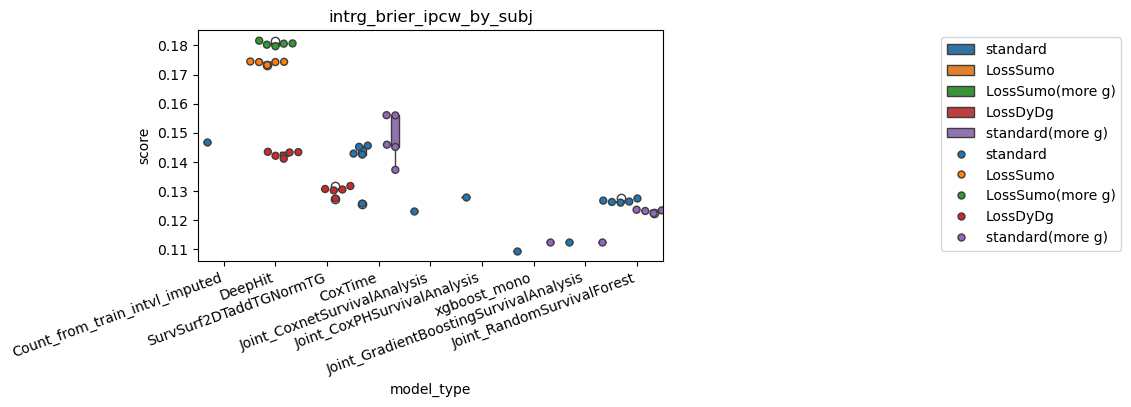

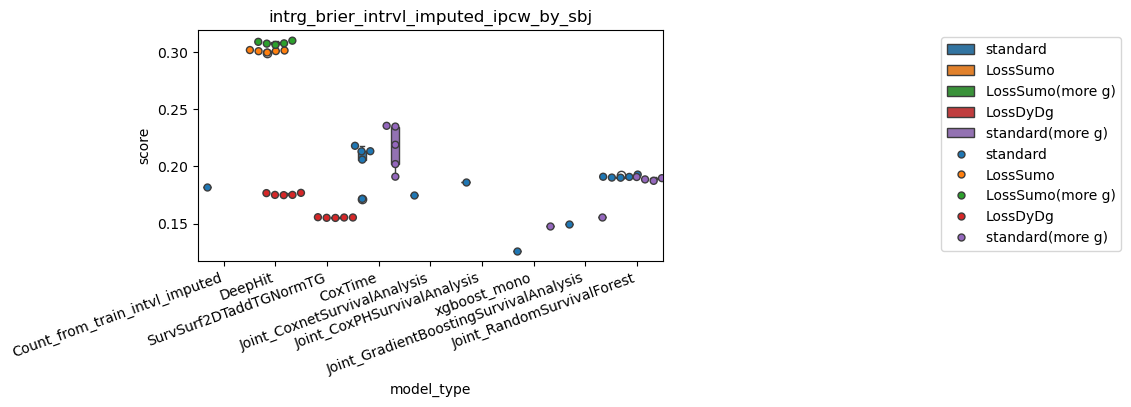

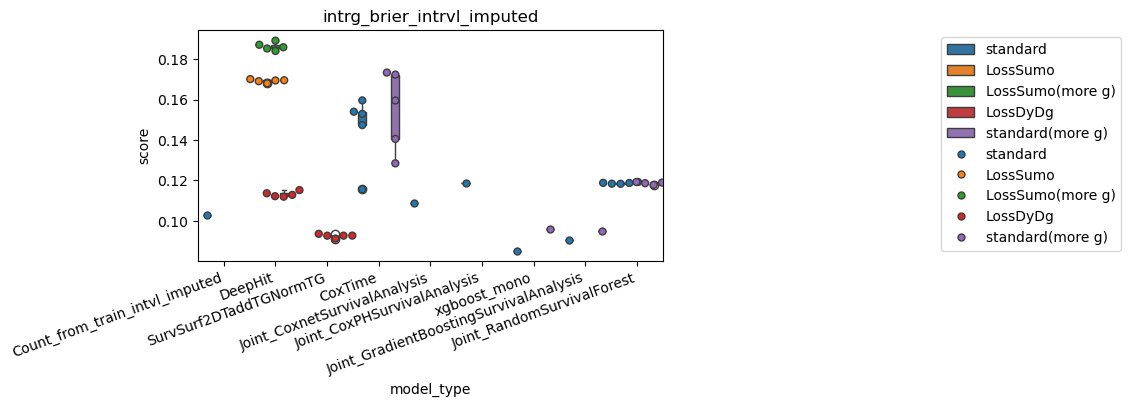

In [27]:
for y in (
    'intrg_brier_ipcw_by_subj',
    'intrg_brier_intrvl_imputed_ipcw_by_sbj',
    'intrg_brier_intrvl_imputed'
):
    fig, ax = plt.subplots(1,1, figsize=(6,3))
    sns.boxplot(
        data=df_model_to_metric,
        y=y,
        x='model_type',
        hue='descriptor',
        ax=ax
    )
    sns.swarmplot(
        data=df_model_to_metric,
        y=y,
        x='model_type',
        hue='descriptor',
        linewidth=1,
        dodge=True,
        ax=ax
    )
    ax.legend(bbox_to_anchor=(2, 1))
    ax.set(ylabel='score', title=y)

    plt.xticks(rotation=20, ha='right')

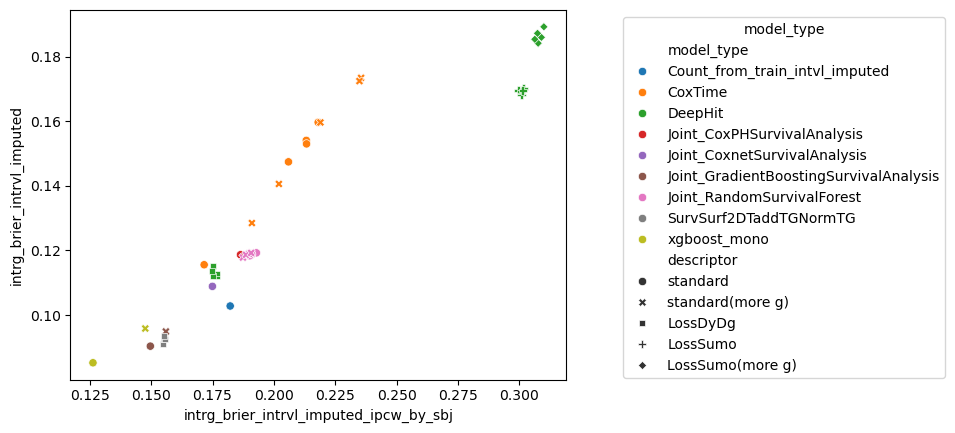

In [28]:
fig, ax = plt.subplots(1,1)

df = df_model_to_metric.copy()
df['max_max_violation'] = df['max_max_violation'].fillna(0)
df = df.sort_values(['model_type','descriptor'])
sns.scatterplot(
    data=df,
    x='intrg_brier_intrvl_imputed_ipcw_by_sbj',
    y='intrg_brier_intrvl_imputed',
    hue='model_type',
    style='descriptor',
    ax=ax,
)
ax.legend(bbox_to_anchor=(1.1, 1), title='model_type')

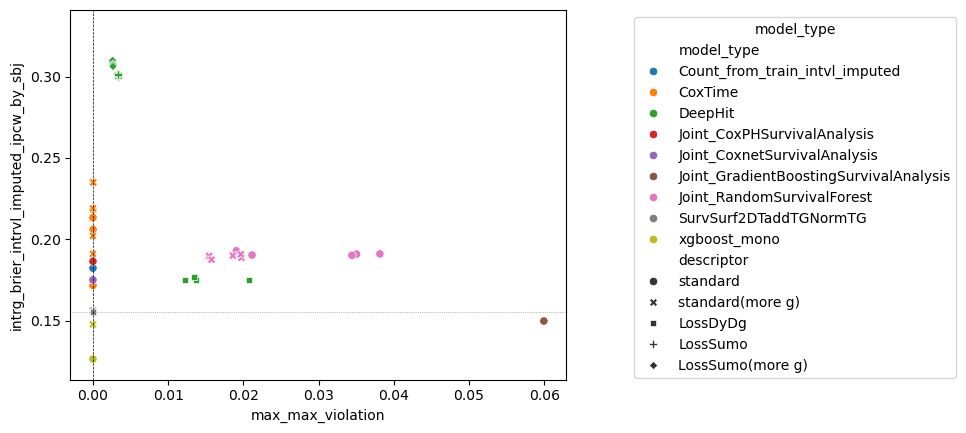

In [29]:
fig, ax = plt.subplots(1,1)
df = df_model_to_metric.copy()
df['max_max_violation'] = df['max_max_violation'].fillna(0)
df = df.sort_values(['model_type','descriptor'])
sns.scatterplot(
    data=df,
    x='max_max_violation',
    y='intrg_brier_intrvl_imputed_ipcw_by_sbj',
    hue='model_type',
    hue_order=sorted(df['model_type'].unique()),
    style='descriptor',
    ax=ax,
)

selector = (df['descriptor'] == 'LossDyDg') & (df['model_type'] == 'SurvSurf2DTaddTGNormTG')
mean_survsurf = df.loc[selector,'intrg_brier_intrvl_imputed_ipcw_by_sbj'].mean()
ax.axhline(y=mean_survsurf, ls=':', color='grey', lw=0.5)

selector = (df['descriptor'] == 'LossDyDgSumoFirstLast2') & (df['model_type'] == 'SurvSurf2DTaddTGNormTG')
mean_survsurf = df.loc[selector,'intrg_brier_intrvl_imputed_ipcw_by_sbj'].mean()
ax.axhline(y=mean_survsurf, ls='--', color='grey', lw=0.5)

ax.axvline(x=0, ls='--', color='black', lw=0.5)
x = df['intrg_brier_intrvl_imputed_ipcw_by_sbj'].copy()
ax.set(ylim=(x.min()*0.9, x.max()*1.1))
ax.legend(bbox_to_anchor=(1.8, 1), title='model_type')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, '(xgboost_mono, standard)'),
  Text(1, 0, '(xgboost_mono, standard(more g))'),
  Text(2, 0, '(Joint_GradientBoostingSurvivalAnalysis, standard)'),
  Text(3, 0, '(SurvSurf2DTaddTGNormTG, LossDyDg)'),
  Text(4, 0, '(Joint_GradientBoostingSurvivalAnalysis, standard(more g))'),
  Text(5, 0, '(Joint_CoxnetSurvivalAnalysis, standard)'),
  Text(6, 0, '(DeepHit, LossDyDg)'),
  Text(7, 0, '(Count_from_train_intvl_imputed, standard)'),
  Text(8, 0, '(Joint_CoxPHSurvivalAnalysis, standard)'),
  Text(9, 0, '(Joint_RandomSurvivalForest, standard(more g))'),
  Text(10, 0, '(Joint_RandomSurvivalForest, standard)'),
  Text(11, 0, '(CoxTime, standard)'),
  Text(12, 0, '(CoxTime, standard(more g))'),
  Text(13, 0, '(DeepHit, LossSumo)'),
  Text(14, 0, '(DeepHit, LossSumo(more g))')])

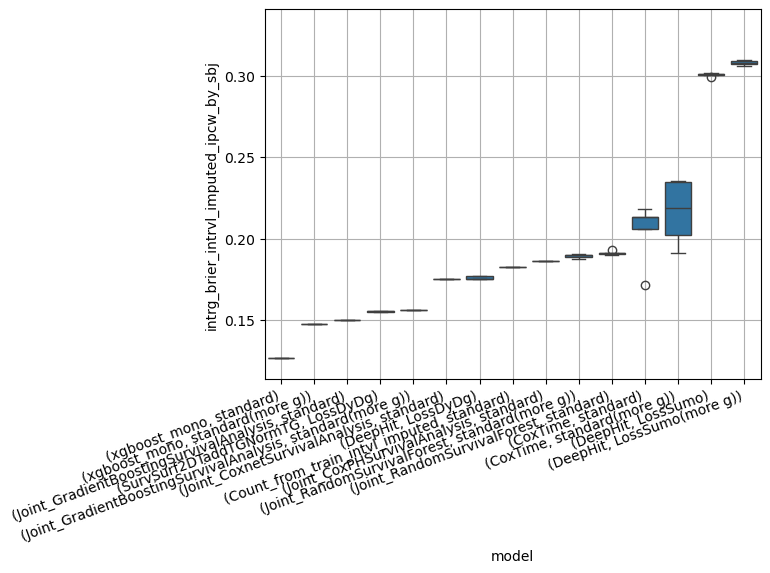

In [30]:
fig, ax = plt.subplots(1,1)
df = df_model_to_metric.copy()
df['max_max_violation'] = df['max_max_violation'].fillna(0)
df = df.sort_values(['model_type','descriptor'])
df['model'] = '(' + df['model_type'] + ', ' + df['descriptor'] + ')'

df['mean_score'] = df['model'].map(df.groupby('model')['intrg_brier_intrvl_imputed_ipcw_by_sbj'].mean().to_dict())
df = df.sort_values('mean_score')
sns.boxplot(
    data=df,
    x='model',
    y='intrg_brier_intrvl_imputed_ipcw_by_sbj',
    ax=ax,
)

ax.set(ylabel='intrg_brier_intrvl_imputed_ipcw_by_sbj')
x = df['intrg_brier_intrvl_imputed_ipcw_by_sbj'].copy()
ax.set(ylim=(x.min()*0.9, x.max()*1.1))
plt.grid()
plt.xticks(rotation=20, ha='right')

In [31]:
df_model_to_metric.groupby(['model_type','descriptor'])['intrg_brier_intrvl_imputed_ipcw_by_sbj'].describe()

count      mean  \
model_type                             descriptor                          
Count_from_train_intvl_imputed         standard            1.0  0.182199   
CoxTime                                standard            5.0  0.204414   
                                       standard(more g)    5.0  0.216475   
DeepHit                                LossDyDg            5.0  0.175723   
                                       LossSumo            5.0  0.300861   
                                       LossSumo(more g)    5.0  0.308027   
Joint_CoxPHSurvivalAnalysis            standard            1.0  0.186400   
Joint_CoxnetSurvivalAnalysis           standard            1.0  0.174962   
Joint_GradientBoostingSurvivalAnalysis standard            1.0  0.149686   
                                       standard(more g)    1.0  0.156018   
Joint_RandomSurvivalForest             standard            5.0  0.191014   
                                       standard(more g)    5.0  0.189285   
SurvSurf2DTaddTGNormTG                 LossDyDg            5.0  0.155256   
xgboost_mono                           standard            1.0  0.126318   
                                       standard(more g)    1.0  0.147613   

                                                              std       min  \
model_type                             descriptor                             
Count_from_train_intvl_imputed         standard               NaN  0.182199   
CoxTime                                standard          0.018848  0.171596   
                                       standard(more g)  0.019761  0.191034   
DeepHit                                LossDyDg          0.000961  0.174889   
                                       LossSumo          0.000818  0.299593   
                                       LossSumo(more g)  0.001437  0.306263   
Joint_CoxPHSurvivalAnalysis            standard               NaN  0.186400   
Joint_CoxnetSurvivalAnalysis           standard               NaN  0.174962   
Joint_GradientBoostingSurvivalAnalysis standard               NaN  0.149686   
                                       standard(more g)       NaN  0.156018   
Joint_RandomSurvivalForest             standard          0.001104  0.190139   
                                       standard(more g)  0.001293  0.187402   
SurvSurf2DTaddTGNormTG                 LossDyDg          0.000250  0.154963   
xgboost_mono                           standard               NaN  0.126318   
                                       standard(more g)       NaN  0.147613   

                                                              25%       50%  \
model_type                             descriptor                             
Count_from_train_intvl_imputed         standard          0.182199  0.182199   
CoxTime                                standard          0.205937  0.213199   
                                       standard(more g)  0.202033  0.218947   
DeepHit                                LossDyDg          0.175089  0.175102   
                                       LossSumo          0.300750  0.300850   
                                       LossSumo(more g)  0.307367  0.307615   
Joint_CoxPHSurvivalAnalysis            standard          0.186400  0.186400   
Joint_CoxnetSurvivalAnalysis           standard          0.174962  0.174962   
Joint_GradientBoostingSurvivalAnalysis standard          0.149686  0.149686   
                                       standard(more g)  0.156018  0.156018   
Joint_RandomSurvivalForest             standard          0.190245  0.190834   
                                       standard(more g)  0.188636  0.189742   
SurvSurf2DTaddTGNormTG                 LossDyDg          0.155061  0.155322   
xgboost_mono                           standard          0.126318  0.126318   
                                       standard(more g)  0.147613  0.147613   

                                                              75%       max 

In [32]:
df_model_to_metric.groupby(['model_type','descriptor'])['intrg_brier_intrvl_imputed'].describe()

count      mean  \
model_type                             descriptor                          
Count_from_train_intvl_imputed         standard            1.0  0.102825   
CoxTime                                standard            5.0  0.145944   
                                       standard(more g)    5.0  0.154910   
DeepHit                                LossDyDg            5.0  0.113203   
                                       LossSumo            5.0  0.169320   
                                       LossSumo(more g)    5.0  0.186372   
Joint_CoxPHSurvivalAnalysis            standard            1.0  0.118686   
Joint_CoxnetSurvivalAnalysis           standard            1.0  0.108899   
Joint_GradientBoostingSurvivalAnalysis standard            1.0  0.090401   
                                       standard(more g)    1.0  0.094929   
Joint_RandomSurvivalForest             standard            5.0  0.118731   
                                       standard(more g)    5.0  0.118738   
SurvSurf2DTaddTGNormTG                 LossDyDg            5.0  0.092576   
xgboost_mono                           standard            1.0  0.085254   
                                       standard(more g)    1.0  0.095857   

                                                              std       min  \
model_type                             descriptor                             
Count_from_train_intvl_imputed         standard               NaN  0.102825   
CoxTime                                standard          0.017516  0.115588   
                                       standard(more g)  0.019841  0.128491   
DeepHit                                LossDyDg          0.001314  0.111979   
                                       LossSumo          0.000775  0.168103   
                                       LossSumo(more g)  0.001936  0.184133   
Joint_CoxPHSurvivalAnalysis            standard               NaN  0.118686   
Joint_CoxnetSurvivalAnalysis           standard               NaN  0.108899   
Joint_GradientBoostingSurvivalAnalysis standard               NaN  0.090401   
                                       standard(more g)       NaN  0.094929   
Joint_RandomSurvivalForest             standard          0.000364  0.118372   
                                       standard(more g)  0.000548  0.117830   
SurvSurf2DTaddTGNormTG                 LossDyDg          0.000875  0.091176   
xgboost_mono                           standard               NaN  0.085254   
                                       standard(more g)       NaN  0.095857   

                                                              25%       50%  \
model_type                             descriptor                             
Count_from_train_intvl_imputed         standard          0.102825  0.102825   
CoxTime                                standard          0.147426  0.152984   
                                       standard(more g)  0.140589  0.159625   
DeepHit                                LossDyDg          0.112238  0.112883   
                                       LossSumo          0.169156  0.169524   
                                       LossSumo(more g)  0.185354  0.185958   
Joint_CoxPHSurvivalAnalysis            standard          0.118686  0.118686   
Joint_CoxnetSurvivalAnalysis           standard          0.108899  0.108899   
Joint_GradientBoostingSurvivalAnalysis standard          0.090401  0.090401   
                                       standard(more g)  0.094929  0.094929   
Joint_RandomSurvivalForest             standard          0.118415  0.118772   
                                       standard(more g)  0.118672  0.118963   
SurvSurf2DTaddTGNormTG                 LossDyDg          0.092687  0.092696   
xgboost_mono                           standard          0.085254  0.085254   
                                       standard(more g)  0.095857  0.095857   

                                                              75%       max 

In [33]:
df_model_to_metric.groupby(['model_type','descriptor'])['max_max_violation'].describe()

count      mean  \
model_type                             descriptor                          
Count_from_train_intvl_imputed         standard            0.0       NaN   
CoxTime                                standard            3.0  0.000005   
                                       standard(more g)    3.0  0.000015   
DeepHit                                LossDyDg            5.0  0.014742   
                                       LossSumo            5.0  0.003327   
                                       LossSumo(more g)    5.0  0.002643   
Joint_CoxPHSurvivalAnalysis            standard            0.0       NaN   
Joint_CoxnetSurvivalAnalysis           standard            0.0       NaN   
Joint_GradientBoostingSurvivalAnalysis standard            1.0  0.059962   
                                       standard(more g)    0.0       NaN   
Joint_RandomSurvivalForest             standard            5.0  0.029573   
                                       standard(more g)    5.0  0.017847   
SurvSurf2DTaddTGNormTG                 LossDyDg            0.0       NaN   
xgboost_mono                           standard            0.0       NaN   
                                       standard(more g)    0.0       NaN   

                                                              std  \
model_type                             descriptor                   
Count_from_train_intvl_imputed         standard               NaN   
CoxTime                                standard          0.000008   
                                       standard(more g)  0.000013   
DeepHit                                LossDyDg          0.003436   
                                       LossSumo          0.000029   
                                       LossSumo(more g)  0.000033   
Joint_CoxPHSurvivalAnalysis            standard               NaN   
Joint_CoxnetSurvivalAnalysis           standard               NaN   
Joint_GradientBoostingSurvivalAnalysis standard               NaN   
                                       standard(more g)       NaN   
Joint_RandomSurvivalForest             standard          0.008783   
                                       standard(more g)  0.002094   
SurvSurf2DTaddTGNormTG                 LossDyDg               NaN   
xgboost_mono                           standard               NaN   
                                       standard(more g)       NaN   

                                                                  min  \
model_type                             descriptor                       
Count_from_train_intvl_imputed         standard                   NaN   
CoxTime                                standard          4.267691e-07   
                                       standard(more g)  4.851259e-06   
DeepHit                                LossDyDg          1.225153e-02   
                                       LossSumo          3.283366e-03   
                                       LossSumo(more g)  2.598590e-03   
Joint_CoxPHSurvivalAnalysis            standard                   NaN   
Joint_CoxnetSurvivalAnalysis           standard                   NaN   
Joint_GradientBoostingSurvivalAnalysis standard          5.996151e-02   
                                       standard(more g)           NaN   
Joint_RandomSurvivalForest             standard          1.906825e-02   
                                       standard(more g)  1.545476e-02   
SurvSurf2DTaddTGNormTG                 LossDyDg                   NaN   
xgboost_mono                           standard                   NaN   
                                       standard(more g)           NaN   

                                                                  25%  \
model_type                             descriptor                       
Count_from_train_intvl_imputed         standard                   NaN   
CoxTime                                standard          5.781845e-07   
                                       standard(more g) 

In [34]:
df_model_to_metric.groupby(['model_type','descriptor'])['max_prop_t_violated'].describe()

count      mean  \
model_type                             descriptor                          
Count_from_train_intvl_imputed         standard            1.0  0.000000   
CoxTime                                standard            5.0  0.025000   
                                       standard(more g)    5.0  0.025000   
DeepHit                                LossDyDg            5.0  0.041667   
                                       LossSumo            5.0  0.041667   
                                       LossSumo(more g)    5.0  0.041667   
Joint_CoxPHSurvivalAnalysis            standard            1.0  0.000000   
Joint_CoxnetSurvivalAnalysis           standard            1.0  0.000000   
Joint_GradientBoostingSurvivalAnalysis standard            1.0  1.000000   
                                       standard(more g)    1.0  0.000000   
Joint_RandomSurvivalForest             standard            5.0  0.775000   
                                       standard(more g)    5.0  0.966667   
SurvSurf2DTaddTGNormTG                 LossDyDg            5.0  0.000000   
xgboost_mono                           standard            1.0  0.000000   
                                       standard(more g)    1.0  0.000000   

                                                              std       min  \
model_type                             descriptor                             
Count_from_train_intvl_imputed         standard               NaN  0.000000   
CoxTime                                standard          0.022822  0.000000   
                                       standard(more g)  0.022822  0.000000   
DeepHit                                LossDyDg          0.000000  0.041667   
                                       LossSumo          0.000000  0.041667   
                                       LossSumo(more g)  0.000000  0.041667   
Joint_CoxPHSurvivalAnalysis            standard               NaN  0.000000   
Joint_CoxnetSurvivalAnalysis           standard               NaN  0.000000   
Joint_GradientBoostingSurvivalAnalysis standard               NaN  1.000000   
                                       standard(more g)       NaN  0.000000   
Joint_RandomSurvivalForest             standard          0.055902  0.708333   
                                       standard(more g)  0.018634  0.958333   
SurvSurf2DTaddTGNormTG                 LossDyDg          0.000000  0.000000   
xgboost_mono                           standard               NaN  0.000000   
                                       standard(more g)       NaN  0.000000   

                                                              25%       50%  \
model_type                             descriptor                             
Count_from_train_intvl_imputed         standard          0.000000  0.000000   
CoxTime                                standard          0.000000  0.041667   
                                       standard(more g)  0.000000  0.041667   
DeepHit                                LossDyDg          0.041667  0.041667   
                                       LossSumo          0.041667  0.041667   
                                       LossSumo(more g)  0.041667  0.041667   
Joint_CoxPHSurvivalAnalysis            standard          0.000000  0.000000   
Joint_CoxnetSurvivalAnalysis           standard          0.000000  0.000000   
Joint_GradientBoostingSurvivalAnalysis standard          1.000000  1.000000   
                                       standard(more g)  0.000000  0.000000   
Joint_RandomSurvivalForest             standard          0.750000  0.750000   
                                       standard(more g)  0.958333  0.958333   
SurvSurf2DTaddTGNormTG                 LossDyDg          0.000000  0.000000   
xgboost_mono                           standard          0.000000  0.000000   
                                       standard(more g)  0.000000  0.000000   

                                                              75%       max 

# Clean up

In [35]:
with torch.no_grad():
    torch.cuda.empty_cache()
gc.collect()

5229